/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc


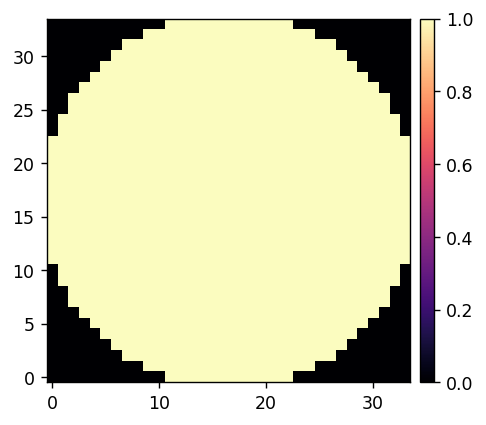

ERROR:purepyindi2.transports:Connection failed. Reconnecting to localhost:7624 in 2 sec...
ERROR:purepyindi2.transports:Failed to connect to localhost:7624
Traceback (most recent call last):
  File "/opt/MagAOX/source/purepyindi2/purepyindi2/transports.py", line 154, in _reconnection_monitor
    self._socket.connect((self.host, self.port))
ConnectionRefusedError: [Errno 111] Connection refused
INFO:purepyindi2.transports:Retrying in 2 sec...
ERROR:purepyindi2.transports:Failed to connect to localhost:7624
Traceback (most recent call last):
  File "/opt/MagAOX/source/purepyindi2/purepyindi2/transports.py", line 154, in _reconnection_monitor
    self._socket.connect((self.host, self.port))
ConnectionRefusedError: [Errno 111] Connection refused
INFO:purepyindi2.transports:Retrying in 2 sec...
ERROR:purepyindi2.transports:Failed to connect to localhost:7624
Traceback (most recent call last):
  File "/opt/MagAOX/source/purepyindi2/purepyindi2/transports.py", line 154, in _reconnection_monit

In [2]:
import numpy as np
import astropy.units as u
from astropy.io import fits
import time 
from importlib import reload
import copy
from datetime import datetime
today = int(datetime.today().strftime('%Y%m%d'))
import os
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize, CenteredNorm
from matplotlib.patches import Circle, Rectangle

from magpyx.utils import ImageStream
import purepyindi
from purepyindi import INDIClient
import purepyindi2
from purepyindi2 import IndiClient
client0 = INDIClient('localhost', 7624)
client0.start()
client = IndiClient()
client.connect()
client.get_properties()

import scoob_llowfsc
from scoob_llowfsc.math_module import xp, xcipy, ensure_np_array
from scoob_llowfsc import utils
from scoob_llowfsc import dm
from scoob_llowfsc import telem
import scoob_llowfsc.scoob_interface as scoobi

print(scoob_llowfsc.path)
data_path = scoob_llowfsc.path/'exp-data'

wavelength_c = 633e-9
camsci_pxscl = 4.6e-6
camsci_pxscl_lamDc = 0.307

dm_mask = ensure_np_array(dm.make_mask(34))
utils.imshow([dm_mask])


In [35]:
camsci_name = 'camlo'
camlo_name = 'camsci'
dm_wfe_name = 'dm00disp01'
dm_lo_name = 'dm00disp02'
dm_ho_name = 'dm00disp03'

camlo_ref_name = 'camlo_ref_0'
camlo_ref_offset_name = 'camlo_ref_offset'

camsci_rawims_path = Path(f'/opt/MagAOX/rawimages/{camsci_name}/')
camlo_rawims_path = Path(f'/opt/MagAOX/rawimages/{camlo_name}/')
camlo_ref_rawims_path = Path(f'/opt/MagAOX/rawimages/{camlo_ref_name}/')
camlo_ref_offset_rawims_path = Path(f'/opt/MagAOX/rawimages/{camlo_ref_offset_name}/')
dm_wfe_rawims_path = Path(f'/opt/MagAOX/rawimages/{dm_wfe_name}/')
dm_lo_rawims_path = Path(f'/opt/MagAOX/rawimages/{dm_lo_name}/')
dm_ho_rawims_path = Path(f'/opt/MagAOX/rawimages/{dm_ho_name}/')

# date = 20250409
date = 20250410
# date = today
exp_path = data_path/f'exp-{date}'
telem_data_path = data_path/f'exp-{date}'/'raw-telem'
unpacked_data_path = data_path/f'exp-{date}'/'unpacked-telem'

In [5]:
telem.make_dir(exp_path)
telem.make_dir(telem_data_path)
telem.make_dir(unpacked_data_path)

Directory '/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250410' already exists.
Directory '/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250410/raw-telem' already exists.
Directory '/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250410/unpacked-telem' already exists.


In [37]:
reload(scoobi)
xc, yc = (3900, 2575)
npsf = 256
scoobi.set_cam_roi(xc, yc, npsf, client0, cam_name=camsci_name, bin_mode=2)
scoobi.set_cam_exp_time(0.001, client0, cam_name=camsci_name,)
scoobi.set_cam_gain(120, client0, cam_name=camsci_name,)
scoobi.set_cam_blacklevel(2, client0, cam_name=camsci_name,)

Set camlo ROI.
Set the camlo exposure time to 1.00e-03s
Set the camlo gain setting to 120.0
Set the camlo blacklevel to 2.0


In [33]:
xc, yc = (5450, 1100) # 1005, 1125
npsf = 512
scoobi.set_cam_roi(xc, yc, npsf, client0, cam_name=camlo_name, bin_mode=2)
scoobi.set_cam_exp_time(0.1, client0, cam_name=camlo_name,)
scoobi.set_cam_gain(120, client0, cam_name=camlo_name,)
scoobi.set_cam_blacklevel(1, client0, cam_name=camlo_name,)

Set camsci ROI.
Set the camsci exposure time to 1.00e-01s
Set the camsci gain setting to 120.0
Set the camsci blacklevel to 1.0


In [38]:
camsci_stream = ImageStream(camsci_name)
camlo_stream = ImageStream(camlo_name)
dm_wfe_stream = ImageStream(dm_wfe_name)
dm_lo_stream = ImageStream(dm_lo_name)
dm_ho_stream = ImageStream(dm_ho_name)

In [36]:
camlo_dims = camlo_stream.shape[:-1]
print(camlo_dims)

scoobi.create_shmim(camlo_ref_name, camlo_dims)
scoobi.create_shmim(camlo_ref_offset_name, camlo_dims)

camlo_ref_stream = ImageStream(camlo_ref_name)
camlo_ref_offset_stream = ImageStream(camlo_ref_offset_name)

(512, 512)


In [41]:
reload(telem)
telem.delete_files(camsci_rawims_path/'*.xrif')
telem.delete_files(camlo_rawims_path/'*.xrif')
telem.delete_files(camlo_ref_rawims_path/'*.xrif')
telem.delete_files(camlo_ref_offset_rawims_path/'*.xrif')
telem.delete_files(dm_wfe_rawims_path/'*.xrif')
telem.delete_files(dm_lo_rawims_path/'*.xrif')
telem.delete_files(dm_ho_rawims_path/'*.xrif')

telem.delete_files(telem_data_path/'*')
telem.delete_files(unpacked_data_path/'*')

In [42]:
telem.toggle(1, camsci_name, client0)
telem.toggle(1, camlo_name, client0)
telem.toggle(1, camlo_ref_name, client0)
telem.toggle(1, camlo_ref_offset_name, client0)
telem.toggle(1, dm_lo_name, client0)
telem.toggle(1, dm_ho_name, client0)

In [43]:
f_command = ensure_np_array(dm.make_f())
ring_command = ensure_np_array(dm.make_ring(rad=10))

for i in range(50):
    # camlo_ref_stream.write( np.random.randn(camlo_dims[0], camlo_dims[1]) )
    # camlo_ref_offset_stream.write( np.random.randn(camlo_dims[0], camlo_dims[1]) )
    camlo_ref_stream.write( i * np.ones(camlo_dims) )
    camlo_ref_offset_stream.write( -i * np.ones(camlo_dims) )
    dm_lo_stream.write(i*f_command)
    dm_ho_stream.write(i*ring_command)
    time.sleep(0.1)

camlo_ref_stream.write(np.zeros(camlo_dims))
camlo_ref_offset_stream.write(np.zeros(camlo_dims))
dm_lo_stream.write(np.zeros((34,34)))
dm_ho_stream.write(np.zeros((34,34)))


In [44]:
telem.toggle(0, camsci_name, client0)
telem.toggle(0, camlo_name, client0)
telem.toggle(0, camlo_ref_name, client0)
telem.toggle(0, camlo_ref_offset_name, client0)
telem.toggle(0, dm_lo_name, client0)
telem.toggle(0, dm_ho_name, client0)

In [61]:
telem.move_files(camsci_rawims_path, telem_data_path)
telem.move_files(camlo_rawims_path, telem_data_path)
telem.move_files(camlo_ref_rawims_path, telem_data_path)
telem.move_files(camlo_ref_offset_rawims_path, telem_data_path)
telem.move_files(dm_lo_rawims_path, telem_data_path)
telem.move_files(dm_ho_rawims_path, telem_data_path)

In [62]:
telem.unpack_data(telem_data_path, unpacked_data_path)

In [6]:
camsci_fnames = telem.get_fnames(unpacked_data_path/f'{camsci_name}_2025*')
camlo_fnames = telem.get_fnames(unpacked_data_path/f'{camlo_name}*')
camlo_ref_fnames = telem.get_fnames(unpacked_data_path/f'{camlo_ref_name}*')
camlo_ref_offset_fnames = telem.get_fnames(unpacked_data_path/f'{camlo_ref_offset_name}*')
dm_lo_fnames = telem.get_fnames(unpacked_data_path/f'{dm_lo_name}*')
dm_ho_fnames = telem.get_fnames(unpacked_data_path/f'{dm_ho_name}*')

In [9]:
camsci_fnames[-5:], camlo_fnames[-5:], camlo_ref_fnames[:5], camlo_ref_offset_fnames[:5], dm_lo_fnames[:5], dm_ho_fnames[:5]

(['/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250410/unpacked-telem/camlo_20250410215425631655289.fits',
  '/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250410/unpacked-telem/camlo_20250410215425638473619.fits',
  '/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250410/unpacked-telem/camlo_20250410215425645349740.fits',
  '/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250410/unpacked-telem/camlo_20250410215425652204132.fits',
  '/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250410/unpacked-telem/camlo_20250410215425659088567.fits'],
 ['/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250410/unpacked-telem/camsci_20250410215425359570977.fits',
  '/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250410/unpacked-telem/camsci_20250410215425459532604.fits',
  '/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250410/u

In [60]:
camlo_ref_stream.write(20*np.random.randn(camlo_dims[0], camlo_dims[1]))

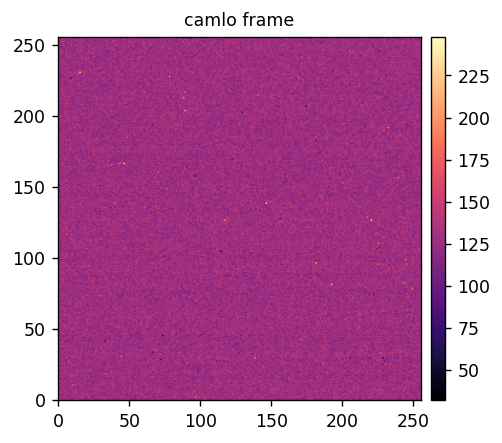

In [ ]:
absolute = 1
camsci_data, camsci_times = telem.read_telem_data(camsci_fnames, absolute=absolute)
utils.imshow(
    [camsci_data[-1]],
    titles=[f'{camsci_name} frame'],
)
camsci_start = camsci_times[0]

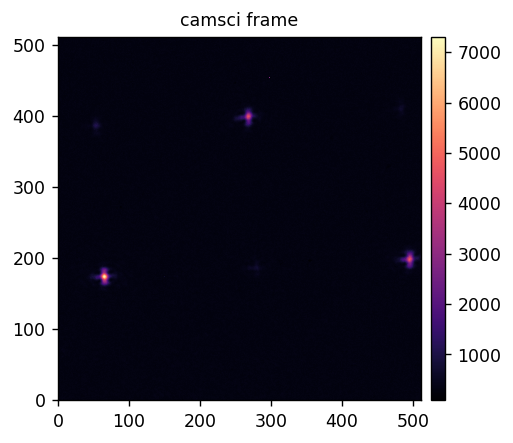

In [29]:
absolute = 1
camlo_data, camlo_times = telem.read_telem_data(camlo_fnames, absolute=absolute)
utils.imshow(
    [camlo_data[4]],
    titles=[f'{camlo_name} frame'],
)
camlo_start = camlo_times[0]

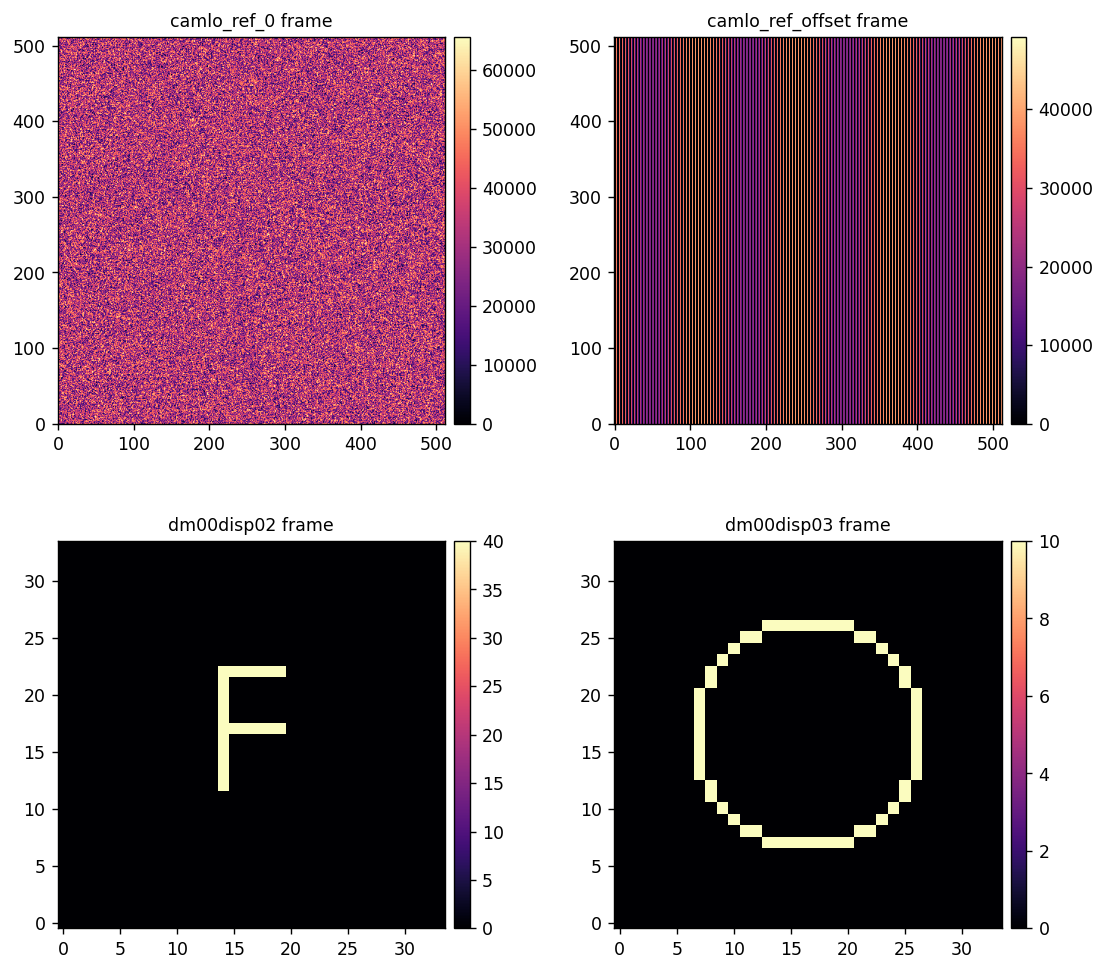

In [30]:
absolute = 1
camlo_ref_data, camlo_ref_times = telem.read_telem_data(camlo_ref_fnames, absolute=absolute)
camlo_ref_offset_data, camlo_ref_offset_times = telem.read_telem_data(camlo_ref_offset_fnames, absolute=absolute)
dm_lo_data, dm_lo_times = telem.read_telem_data(dm_lo_fnames, absolute=absolute)
dm_ho_data, dm_ho_times = telem.read_telem_data(dm_ho_fnames, absolute=absolute)

camlo_ref_start = camlo_ref_times[0]
camlo_ref_offset_start = camlo_ref_offset_times[0]
dm_lo_start = dm_lo_times[0]
dm_ho_start = dm_ho_times[0]

utils.imshow(
    [camlo_ref_data[-1], camlo_ref_offset_data[5], 
     dm_lo_data[40], dm_ho_data[10]],
    titles=[f'{camlo_ref_name} frame',
            f'{camlo_ref_offset_name} frame',
            f'{dm_lo_name} frame',
            f'{dm_ho_name} frame'],
    figsize=(10,10),
    Nrows=2, Ncols=2,
    wspace=0.35, 
    hspace=0.1,
)


In [31]:
first_start = np.min([camsci_start, camlo_start, camlo_ref_start, camlo_ref_offset_start, dm_lo_start, dm_ho_start])

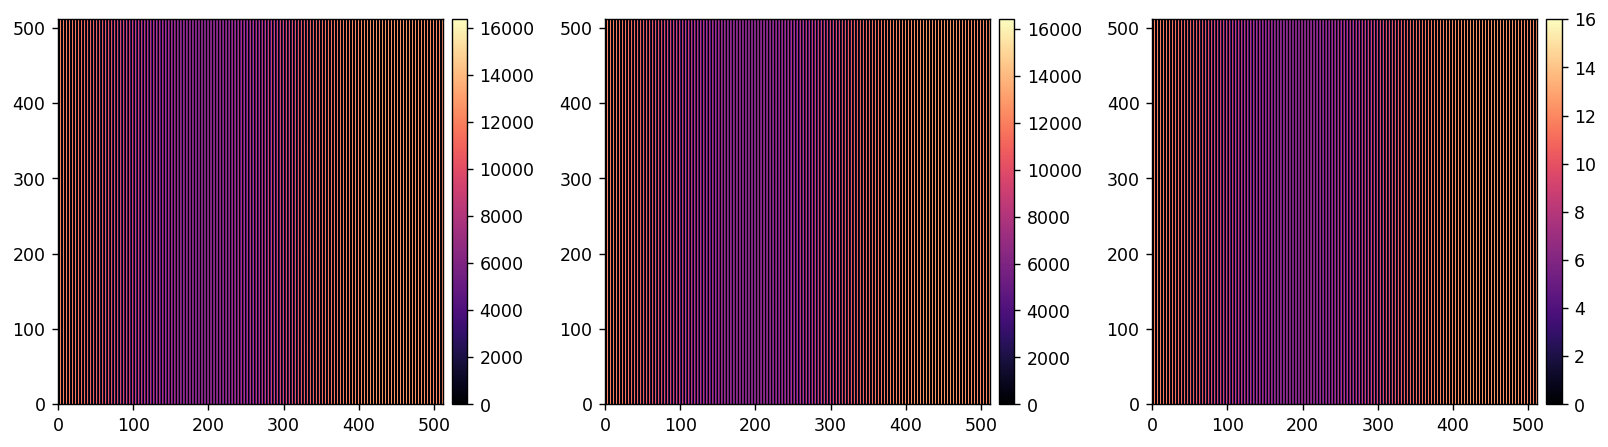

In [32]:
utils.imshow(
    [camlo_ref_data[0], camlo_ref_data[20], camlo_ref_data[20]-camlo_ref_data[10]],
)

Text(0.5, 1.0, 'dm00disp03 Times')

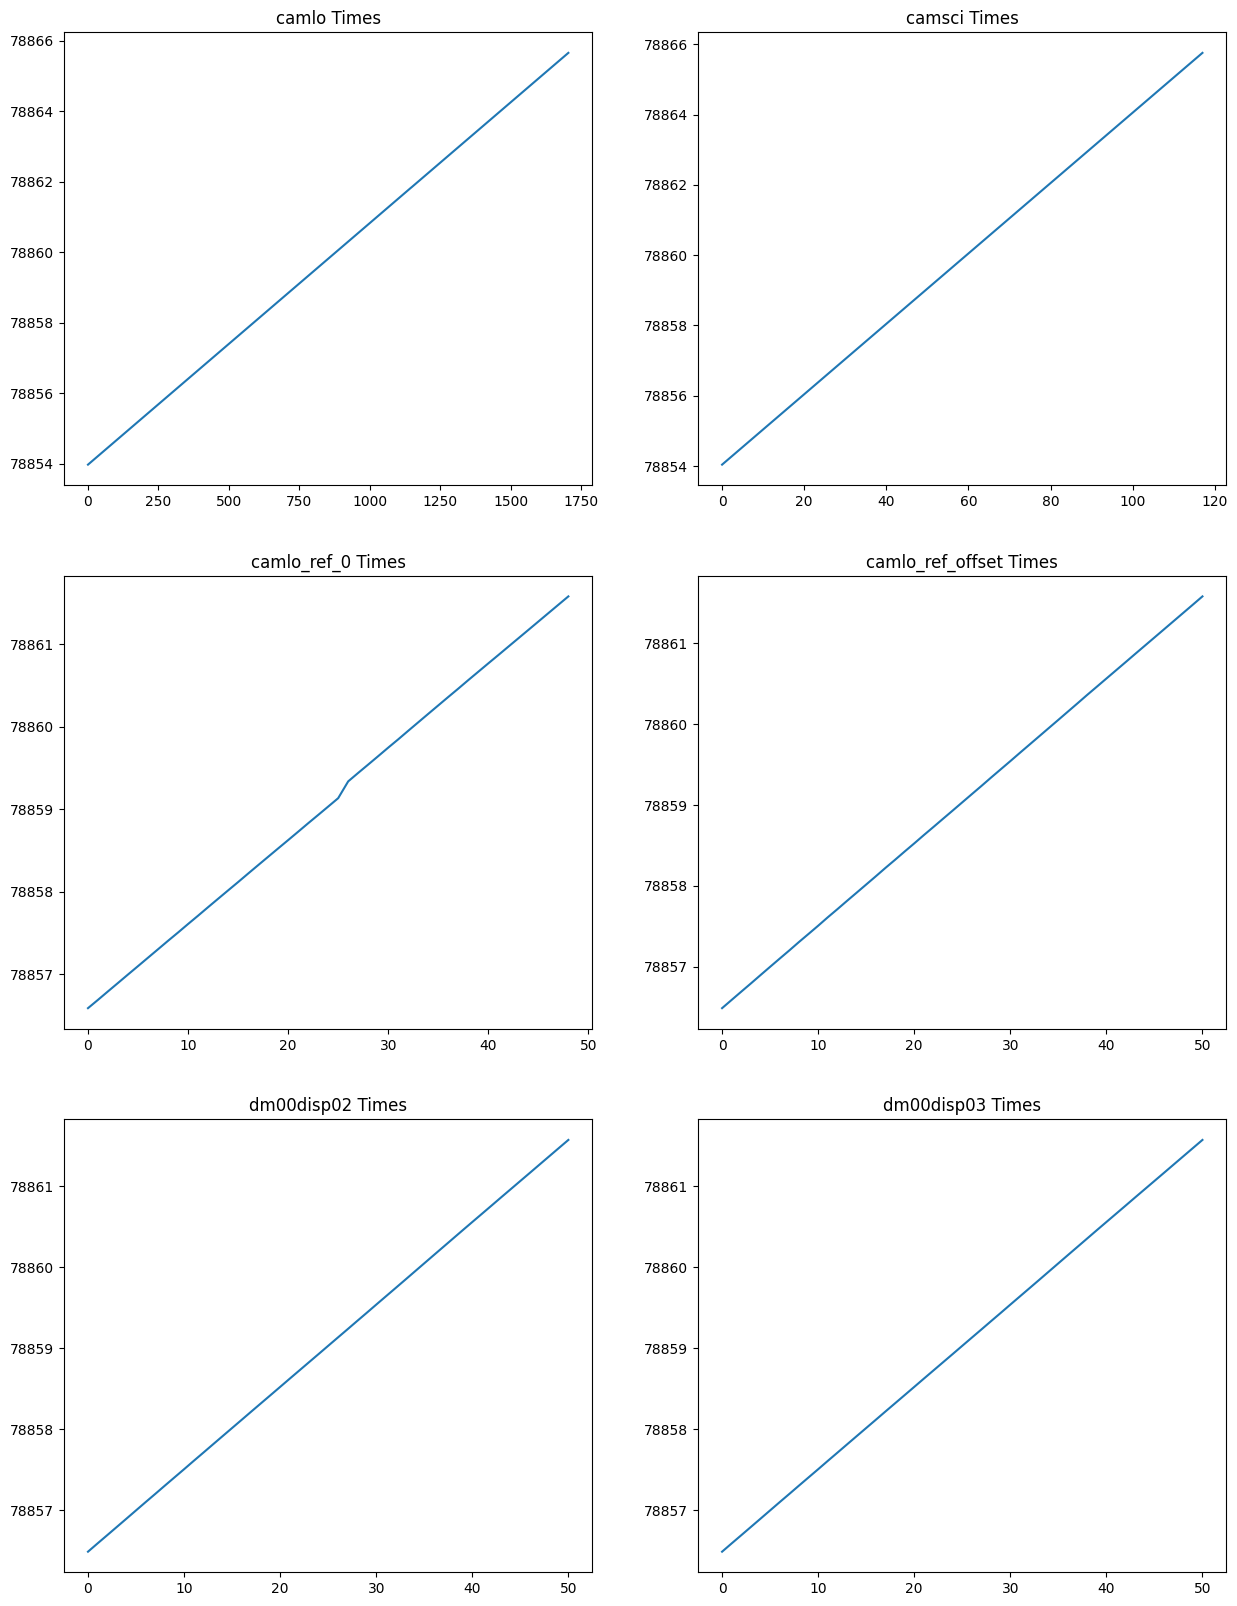

In [33]:
fig = plt.figure(figsize=(15,20))
plt.subplot(321)
plt.plot(camsci_times)
plt.title(f'{camsci_name} Times')

plt.subplot(322)
plt.plot(camlo_times)
plt.title(f'{camlo_name} Times')

plt.subplot(323)
plt.plot(camlo_ref_times[:-1])
plt.title(f'{camlo_ref_name} Times')

plt.subplot(324)
plt.plot(camlo_ref_offset_times)
plt.title(f'{camlo_ref_offset_name} Times')

plt.subplot(325)
plt.plot(dm_lo_times)
plt.title(f'{dm_lo_name} Times')

plt.subplot(326)
plt.plot(dm_ho_times)
plt.title(f'{dm_ho_name} Times')


(0.0, 52.5)

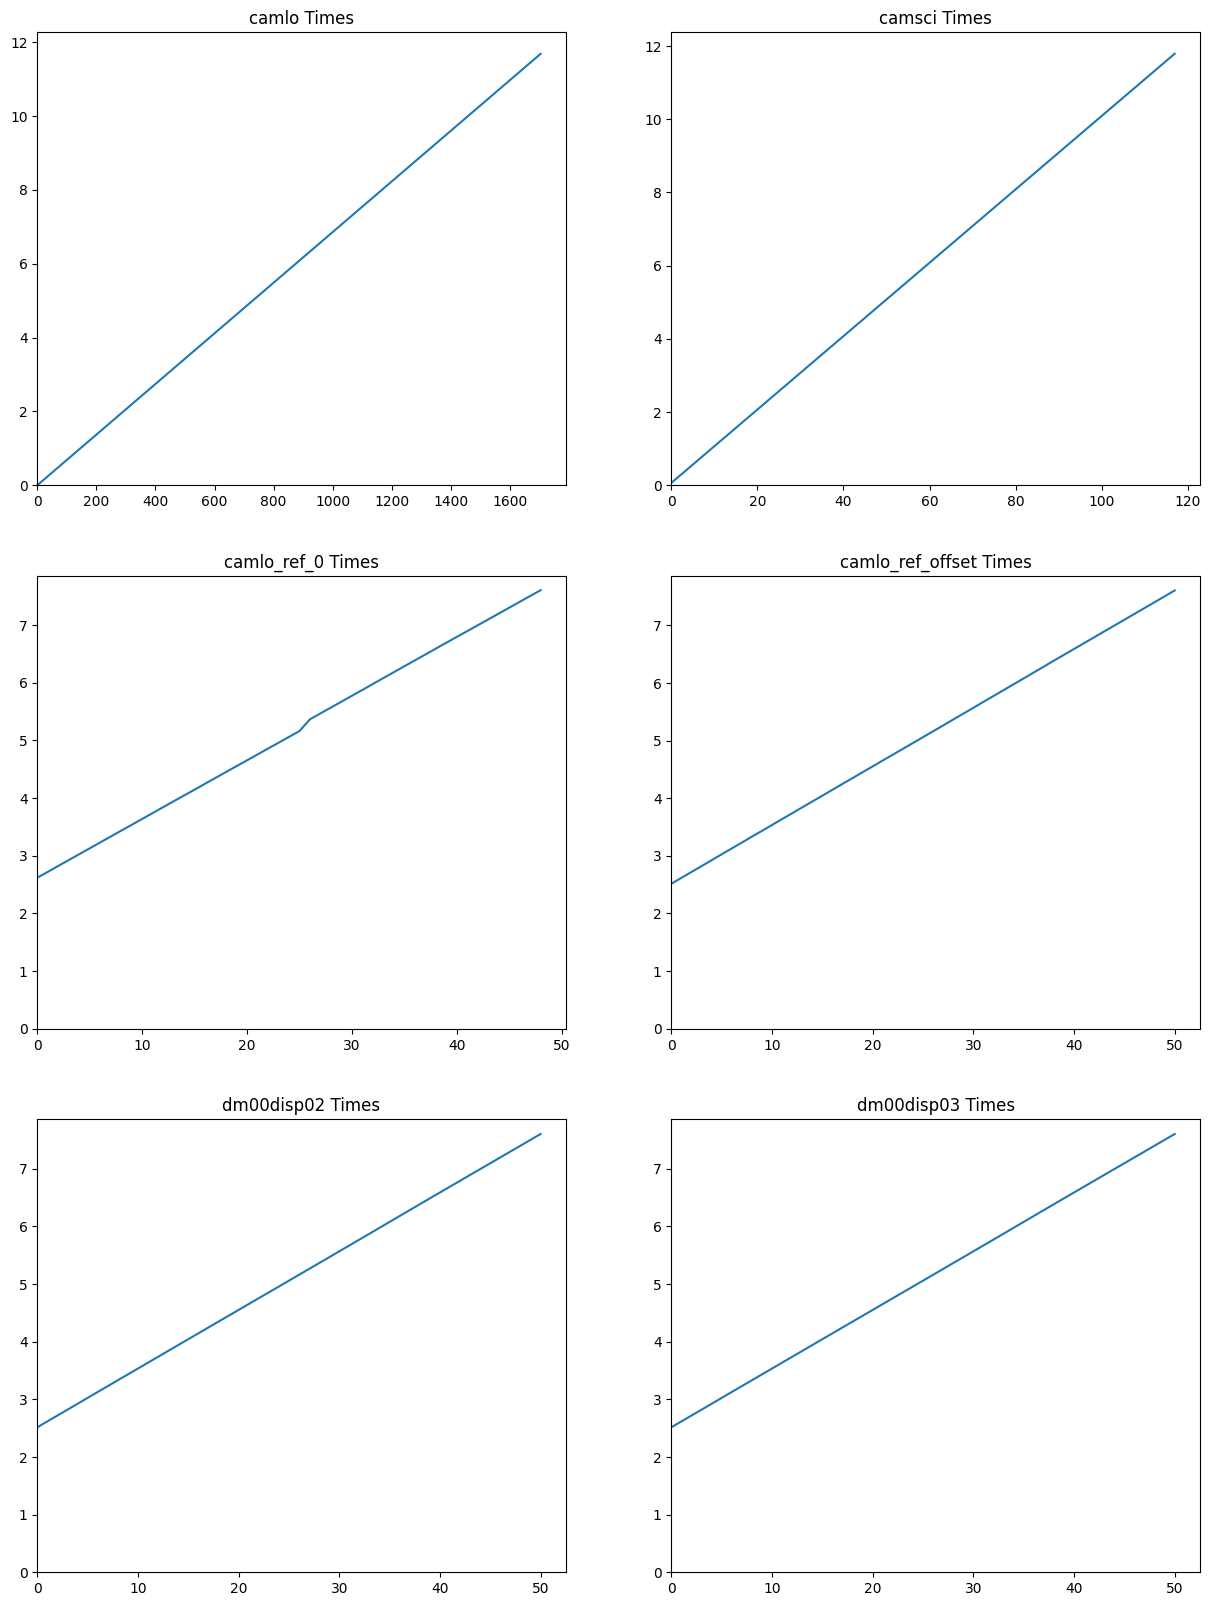

In [40]:
fig = plt.figure(figsize=(15,20))
plt.subplot(321)
plt.plot(camsci_times-first_start)
plt.title(f'{camsci_name} Times')
plt.ylim(0)
plt.xlim(0)

plt.subplot(322)
plt.plot(camlo_times-first_start)
plt.title(f'{camlo_name} Times')
plt.ylim(0)
plt.xlim(0)

plt.subplot(323)
plt.plot(camlo_ref_times[:-1]-first_start)
plt.title(f'{camlo_ref_name} Times')
plt.ylim(0)
plt.xlim(0)

plt.subplot(324)
plt.plot(camlo_ref_offset_times-first_start)
plt.title(f'{camlo_ref_offset_name} Times')
plt.ylim(0)
plt.xlim(0)

plt.subplot(325)
plt.plot(dm_lo_times-first_start)
plt.title(f'{dm_lo_name} Times')
plt.ylim(0)
plt.xlim(0)

plt.subplot(326)
plt.plot(dm_ho_times-first_start)
plt.title(f'{dm_ho_name} Times')
plt.ylim(0)
plt.xlim(0)

In [104]:
telem.delete_files(telem_data_path/'*')
telem.delete_files(unpacked_data_path/'*')